# Simulation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML
import matplotlib 
matplotlib.rc('font', family='serif')
matplotlib.rc('font', serif='STIXGeneral')
from cmcrameri import cm  #cmap=cm.lipari 
matplotlib.rcParams['animation.embed_limit'] = 50  # MB

### Global variables

In [ ]:
dimension = 256*2 #size of matrix
background_num = 5 #No. of background objects # updated from original
frames_num = 50    # number of animation frames 


## Object & background 

In [ ]:
# Fixed background
random_num = np.random.default_rng(2)
bg_positions = random_num.integers(0.2*dimension,0.8*dimension, size=(background_num, 2))

In [ ]:

# Object matrix
def make_object(t):
    '''creates a vertical and horizontal linear moving object relative to a fixed background'''

    Obj = np.zeros((dimension, dimension))

    # Static background dots
    for y, x in bg_positions:
        Obj[y, x] = 1

    centre_x = dimension // 2
    centre_y = dimension // 2
    amp_x = 60
    amp_y = 60

    # Object 1 (horizontal figure 8)
    x1 = int(centre_x  + amp_x * np.sin(t)) +50
    y1 = int(centre_y + amp_y * np.sin(2 * t))

    # Object 2 (vertical figure 8)
    x2 = int(centre_x  + amp_x * np.sin(2 * t))
    y2 = int(centre_y + amp_y * np.sin(t))

    Obj[y1, x1] = 1
    Obj[y2, x2] = 1

    Obj = gaussian_filter(Obj, sigma=2)

    return Obj

### Animation

In [ ]:
# animation
fig, ax = plt.subplots()
img = ax.imshow(make_object(0), origin='lower',cmap=cm.lipari )
ax.set_title("Moving dot animation")
bg_frame=[]

def animation_make_object(frame):
    '''inputs value for t to make each image frame'''
    t = 2 * np.pi * frame / frames_num
    img.set_data(make_object(t))
    bg_frame.append(make_object(t))
    return [img]

anim = FuncAnimation(fig, animation_make_object, frames=frames_num, interval=80)
HTML(anim.to_jshtml())

In [ ]:
# Save object video
'''gif_writer = PillowWriter(fps=15)
anim.save("moving_two_object_linear2.0.gif", writer=gif_writer)'''
'''from matplotlib.animation import FFMpegWriter

video_writer = FFMpegWriter(fps=15)
anim.save("moving_two_object_linear2.0.mp4", writer=video_writer)'''

## Random Speckle Pattern

In [ ]:
# Coordinate grid, 0 centred 
Y, X = np.indices((dimension, dimension))
X = X - dimension//2
Y = Y - dimension//2

#gaussian envelope
sigma_env = 80 #standard deviation # updated from original  
gaussian_env = np.exp(-(X**2 + Y**2) / (2 * sigma_env**2))

# Random complex matrix
rand_complex = (
    np.random.uniform(-1, 1, (dimension, dimension)) + 1j * np.random.uniform(-1, 1, (dimension, dimension))
)

# field at barrier
field = rand_complex * gaussian_env


# speckle pattern - random
speckle_rand = np.fft.fftshift(np.fft.fft2(field)) # fast fourier transform, shift to centre
intensity_rand = np.abs(speckle_rand)**2

plt.imshow(intensity_rand, origin='lower',cmap=cm.lipari )
plt.title("|S|^2  (Speckle)")
plt.show()

## Tracking Object

In [ ]:

prev_image_clean = None
fft_speckle = np.fft.fft2(intensity_rand)
frame_list=[]

def track_object(frame):
    '''convolve object and speckle, track object using correlation I(t) ⋆ I(t-1) - I(t) ⋆ I(t)'''
    
    global prev_image_clean
    global fft_speckle
    t = 2 * np.pi * frame / frames_num
    Obj = make_object(t)

    # Convolution of speckle and object
    image = np.fft.ifft2(np.fft.fft2(Obj) * fft_speckle)
    image = np.real(image)

    # Remove background
    image_clean = image - np.mean(image)

    # for first frame
    if prev_image_clean is None:
        prev_image_clean = image_clean
        img.set_data(image_clean)
        img.set_clim(vmin=image_clean.min(), vmax=image_clean.max())
        return [img]

    # correlation - I(t) ⋆ I(t-1)
    correlation_shift = np.fft.ifft2(np.fft.fft2(image_clean) * np.conj(np.fft.fft2(prev_image_clean)))

    # correlation - I(t) ⋆ I(t)
    correlation_auto = np.fft.ifft2(np.fft.fft2(image_clean) * np.conj(np.fft.fft2(image_clean)))

    result = np.real(correlation_shift - correlation_auto)
    result = np.fft.fftshift(result)
    result=np.real(result)
    
    result -= np.mean(result)

    img.set_data(result)
    img.set_clim(vmin=result.min(), vmax=result.max())
    
    prev_image_clean = image_clean
    frame_list.append(result)

    return [img]

fig, ax = plt.subplots()
img = ax.imshow(np.zeros_like(intensity_rand), cmap=cm.lipari, animated=True,origin='lower',)

ax.set_title("Tracking")

#create animation
animation_tracking = FuncAnimation(fig, track_object, frames=frames_num, interval=80)

HTML(animation_tracking.to_jshtml())


# Background Shift Tracking

## Background shifts

In [ ]:
from scipy.ndimage import gaussian_filter


reference_background = bg_frame[0]
reference_background = np.asarray(reference_background,dtype=float)

comparison_frame = np.asarray(frame_list[2],dtype=float)


#Calculate the cross-correlation 

reference_norm = np.sqrt(np.sum(reference_background**2))
comparison_frame_norm = np.sqrt(np.sum(comparison_frame**2))

correlation = np.fft.ifft2(np.fft.fft2(comparison_frame) * np.conj(np.fft.fft2(reference_background)))
correlation = np.real(correlation)
correlation = np.fft.fftshift(correlation)

# Normalise
correlation /= (reference_norm *comparison_frame_norm)


#Find the two strongest peaks

smooth = gaussian_filter(correlation,sigma=2)
flat = smooth.ravel()

candidates = np.argsort(flat)[::-1] # Look from highest correlation to lowest
peaks = []
min_separation = 20

for index in candidates:
    y, x = np.unravel_index(index,correlation.shape)

    too_close = False
    for py, px in peaks:
        distance = np.sqrt((y - py)**2 +(x - px)**2)
        if distance < min_separation:
            too_close = True
            break
    if not too_close:
        peaks.append((y, x))
    if len(peaks) == 2:
        break

# Convert peak positions into shifts

centre_y = correlation.shape[0] // 2
centre_x = correlation.shape[1] // 2

for i, (y, x) in enumerate(peaks):
    dx = x - centre_x
    dy = y - centre_y
    peak_value = correlation[y, x]
    print(
        f"Background {i+1}: "
        f"dx = {dx}, "
        f"dy = {dy}, "
        f"correlation peak = {peak_value}")







## Shift Check

#check shift by moving background by shift amount

fig, ax = plt.subplots(figsize=(8, 8))

# First tracking frame
ax.imshow(comparison_frame,origin='lower',cmap=cm.lipari)

# Original background positions
bg_positions_array = np.array(bg_positions)
original_y = bg_positions_array[:, 0]
original_x = bg_positions_array[:, 1]

# Background 1
y1, x1 = peaks[0]
dx1 = x1 - centre_x
dy1 = y1 - centre_y

ax.scatter(
    original_x + dx1,
    original_y + dy1,
    s=120,
    facecolors='none',
    edgecolors='blue',
    linewidths=2,
    label="Background 1"
)

# Background 2
y2, x2 = peaks[1]

dx2 = x2 - centre_x
dy2 = y2 - centre_y

ax.scatter(
    original_x + dx2,
    original_y + dy2,
    s=120,
    facecolors='none',
    edgecolors='red',
    linewidths=2,
    label="background 2"
)


ax.set_xlim(0, dimension)
ax.set_ylim(0, dimension)

ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_title("Calculated shifts")

ax.legend()

plt.show()

## Shifts For All Frames

In [30]:
y_shifts = []
x_shifts = []
for n in range(len(frame_list)-1):
    reference_background = bg_frame[0]
    reference_background = np.asarray(reference_background,dtype=float)

    comparison_frame = np.asarray(frame_list[n+1],dtype=float)


    #Calculate the cross-correlation 

    reference_norm = np.sqrt(np.sum(reference_background**2))
    comparison_frame_norm = np.sqrt(np.sum(comparison_frame**2))

    correlation = np.fft.ifft2(np.fft.fft2(comparison_frame) * np.conj(np.fft.fft2(reference_background)))
    correlation = np.real(correlation)
    correlation = np.fft.fftshift(correlation)

    # Normalise
    if comparison_frame_norm == 0:
        print(f"Frame {n+1} has zero norm")
    if reference_norm > 0 and comparison_frame_norm > 0:
        correlation /= (reference_norm * comparison_frame_norm)
    else:
        print(f"Skipping frame {n+1}")
        continue

    #Find the two strongest peaks

    smooth = gaussian_filter(correlation,sigma=2)
    flat = smooth.ravel()

    candidates = np.argsort(flat)[::-1] # Look from highest correlation to lowest
    peaks = []
    min_separation = 20

    for index in candidates:
        y, x = np.unravel_index(index,correlation.shape)

        too_close = False
        for py, px in peaks:
            distance = np.sqrt((y - py)**2 +(x - px)**2)
            if distance < min_separation:
                too_close = True
                break
        if not too_close:
            peaks.append((y, x))
        if len(peaks) == 2:
            break

    # Convert peak positions into shifts

    centre_y = correlation.shape[0] // 2
    centre_x = correlation.shape[1] // 2

    for i, (y, x) in enumerate(peaks):
        dx = x - centre_x
        dy = y - centre_y
        y_shifts.append(dy)
        x_shifts.append(dx)




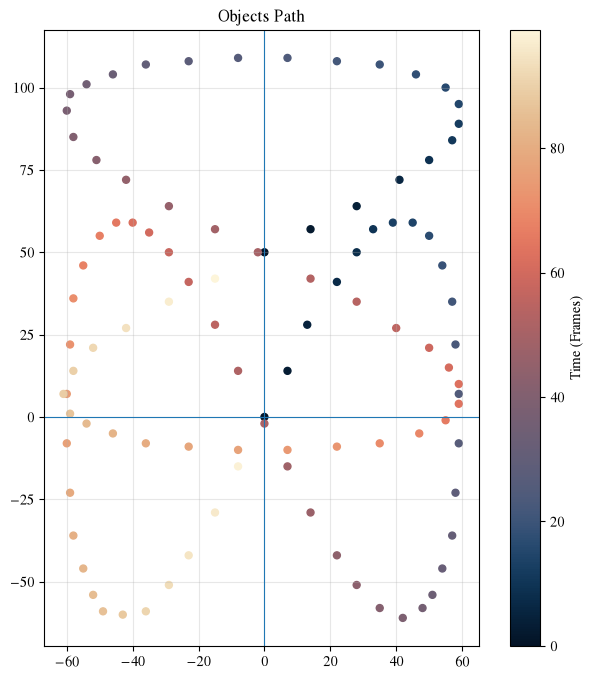

In [31]:
fig, ax = plt.subplots(figsize=(8, 8)) 
x_shifts = np.array(x_shifts)
y_shifts = np.array(y_shifts)

# Plot endpoints, coloured by frame number
scatter = ax.scatter(
    -y_shifts,
    -x_shifts,
    s=25,
    c=np.arange(len(x_shifts)),
    cmap=cm.lipari
)

plt.colorbar(scatter, ax=ax, label='Time (Frames)')
ax.axhline(0, linewidth=0.8) 
ax.axvline(0, linewidth=0.8) 

ax.set_title('Objects Path') 
ax.set_aspect('equal', adjustable='box') 
ax.grid(True, alpha=0.3) 

plt.show()